In [1]:
# importing necessary libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("brain_tumor_dataset.csv") # Loading the dataset 

In [3]:
### The dataset selected is focused on brain tumor characteristics, including features such as Age, Tumor Size, Survival Rate, Tumor Type, and Tumor Growth Rate.
### This type of data is crucial in understanding the relationship between clinical factors and survival outcomes, making it highly relevant for medical research.
### The objective of the project is to predict the survival rate of individuals based on their clinical characteristics, which is a fundamental problem in health informatics and predictive modeling. 
### Therefore, this dataset is well-suited to our research question: “What factors predict survival rates in brain tumor patients?”

In [4]:
### The primary limitation of the dataset is its limited representation of only two tumor types, which significantly hinders the desired output and interpretation. 

In [5]:
# Handling missing values
df.ffill(inplace=True)
df.bfill(inplace=True)

In [7]:
df.drop_duplicates(inplace=True) # Removing duplicates 

In [13]:
# Removing rows where age is less or equal to 0, tumor size is negative, or survival rate is within the range  
df = df[df['Age'] > 0]  
df = df[df['Tumor_Size'] >= 0]  
df = df[df['Survival_Rate'].between(0, 100)]

In [15]:
### Duplicates are eliminated to maintain the integrity of the dataset.
### If there are repeated rows, the model will learn redundant patterns, which can lead to biased learning. Therefore, removing them prevents such biases.
### We filter out records where Age <= 0 or Tumor_Size < 0, as these values are illogical and could distort analysis or model performance.
### Similarly, ensuring that Survival_Rate is within the range 0–100 ensures that our data is reasonable and does not contain extreme outliers or invalid values.

In [17]:
# Converting tumor type into numerical types and standardizing gender 
df['Gender'] = df['Gender'].replace({'Male': 'M', 'Female': 'F'}) 
pd.set_option('future.no_silent_downcasting', True) 
df['Tumor_Type'] = df['Tumor_Type'].replace({'Benign': 0, 'Malignant': 1})

In [19]:
# Handling the outliers 
numeric_cols = ['Age', 'Tumor_Size', 'Survival_Rate', 'Tumor_Growth_Rate']
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

In [21]:
# Standardizing text colomns 
df['Gender'] = df['Gender'].str.capitalize()
df['Location'] = df['Location'].str.title()
df['Histology'] = df['Histology'].str.title()
df['Stage'] = df['Stage'].astype(str).str.upper()

In [23]:
### Gender and tumor type are standardized to simple abbreviations (e.g., Male -> M, Female -> F). 
### This choice ensures consistency in categorical variables, facilitating their seamless integration into machine learning models.
### For the Stage, we convert it to uppercase, ensuring uniformity across the dataset when handling cases where the format may vary.

In [25]:
# Displaying the summary
print("Data Summary After Cleaning:")
print(df.info())
print(df.describe())

Data Summary After Cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           20000 non-null  int64  
 1   Age                  20000 non-null  float64
 2   Gender               20000 non-null  object 
 3   Tumor_Type           20000 non-null  object 
 4   Tumor_Size           20000 non-null  float64
 5   Location             20000 non-null  object 
 6   Histology            20000 non-null  object 
 7   Stage                20000 non-null  object 
 8   Symptom_1            20000 non-null  object 
 9   Symptom_2            20000 non-null  object 
 10  Symptom_3            20000 non-null  object 
 11  Radiation_Treatment  20000 non-null  object 
 12  Surgery_Performed    20000 non-null  object 
 13  Chemotherapy         20000 non-null  object 
 14  Survival_Rate        20000 non-null  float64
 15  Tumor_G

In [27]:
# Applying label encoding to categorical columns 
label_enc = LabelEncoder()
categorical_cols = ['Gender', 'Tumor_Type', 'Location', 'Histology', 'Stage', 'Symptom_1', 'Symptom_2', 'Symptom_3',
                    'Radiation_Treatment', 'Surgery_Performed', 'Chemotherapy', 'Family_History', 'MRI_Result',
                    'Follow_Up_Required']

categorical_cols = [col for col in categorical_cols if col in df.columns]
for col in categorical_cols:
    df[col] = label_enc.fit_transform(df[col])

In [29]:
### Label encoding is employed to transform categorical variables (e.g., Gender, Tumor_Type, Location, Histology, etc.) into numerical representations.
### This approach is suitable for such variables, which are ordinal or nominal in nature. 
### The numerical representation does not imply any ordering or ranking, but rather facilitates data transformation for modeling purposes.
### Numeric features, such as Age, Tumor_Size, and Tumor_Growth_Rate, are standardized using StandardScaler.
### This ensures that all numeric features are scaled to a common range, which is crucial when employing models like linear regression.
### Linear regression models are sensitive to the magnitude of input features, and feature scaling helps maintain consistency in the input data.

In [31]:
# Standardizing numeric colomns 
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [33]:
# Displaying summary stats 
print("Summary Statistics:")
print(df.describe())

Summary Statistics:
         Patient_ID           Age        Gender   Tumor_Type    Tumor_Size  \
count  20000.000000  2.000000e+04  20000.000000  20000.00000  2.000000e+04   
mean   10000.500000 -9.450218e-17      0.499200      0.50150  1.037392e-16   
std     5773.647028  1.000025e+00      0.500012      0.50001  1.000025e+00   
min        1.000000 -1.692676e+00      0.000000      0.00000 -1.719551e+00   
25%     5000.750000 -8.875624e-01      0.000000      0.00000 -8.713193e-01   
50%    10000.500000 -2.494125e-02      0.000000      1.00000 -1.302598e-02   
75%    15000.250000  8.951880e-01      1.000000      1.00000  8.669190e-01   
max    20000.000000  1.700301e+00      1.000000      1.00000  1.729254e+00   

           Location     Histology         Stage     Symptom_1     Symptom_2  \
count  20000.000000  20000.000000  20000.000000  20000.000000  20000.000000   
mean       1.515050      1.503700      1.495150      1.494950      1.504800   
std        1.119882      1.115952      1

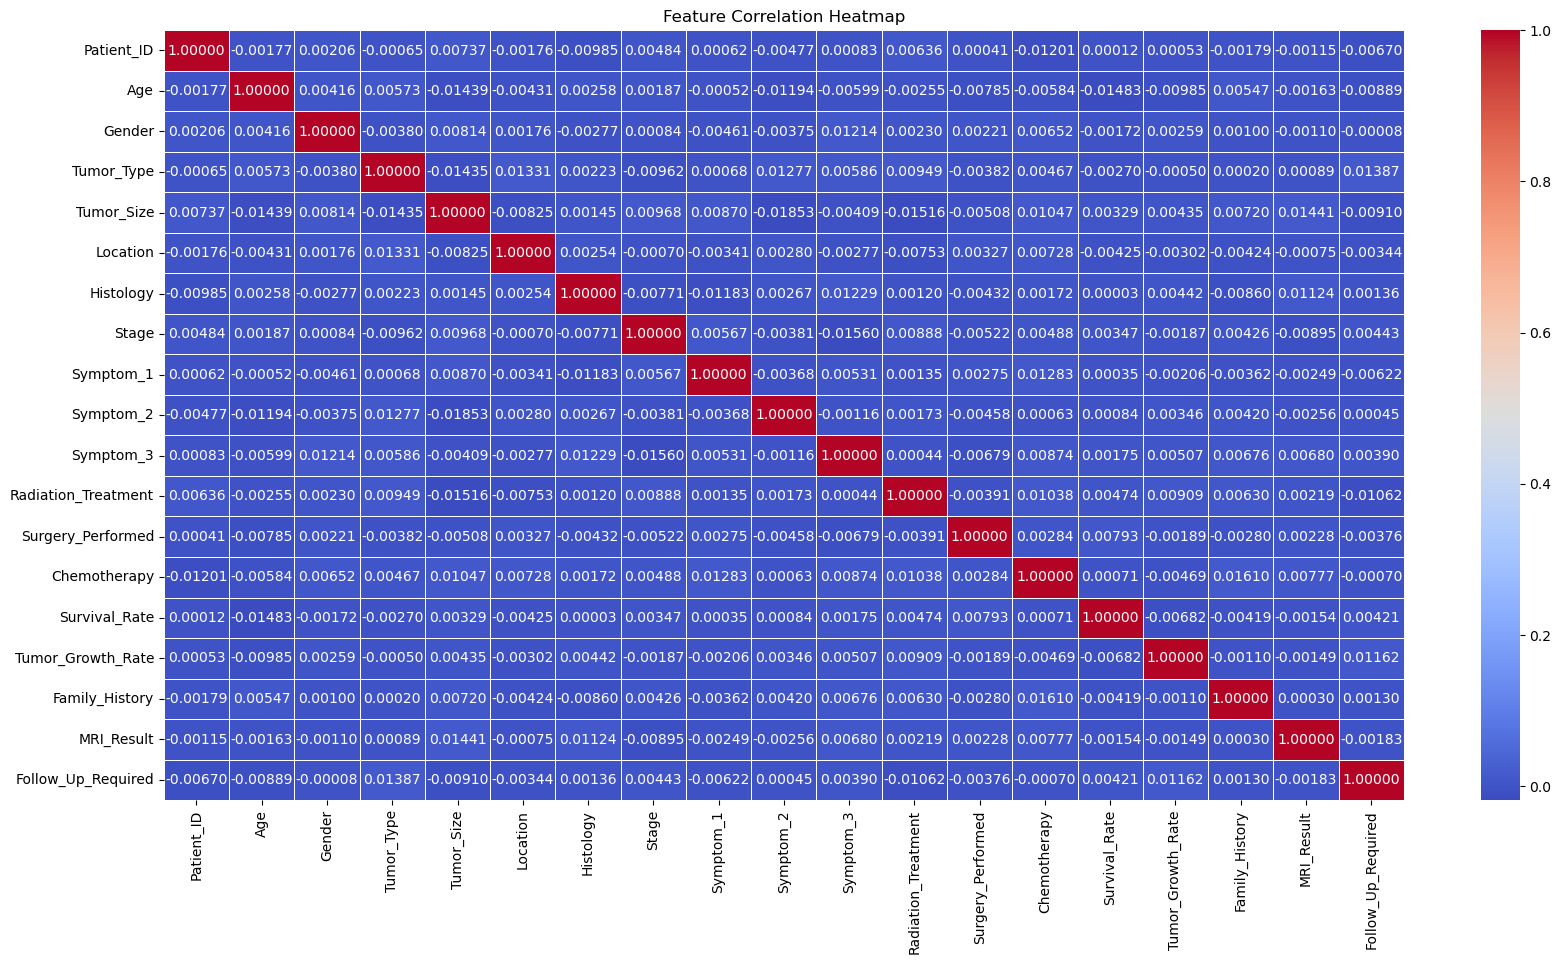

In [35]:
# Heatmap for correlation between variables 
plt.figure(figsize=(20, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.5f', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

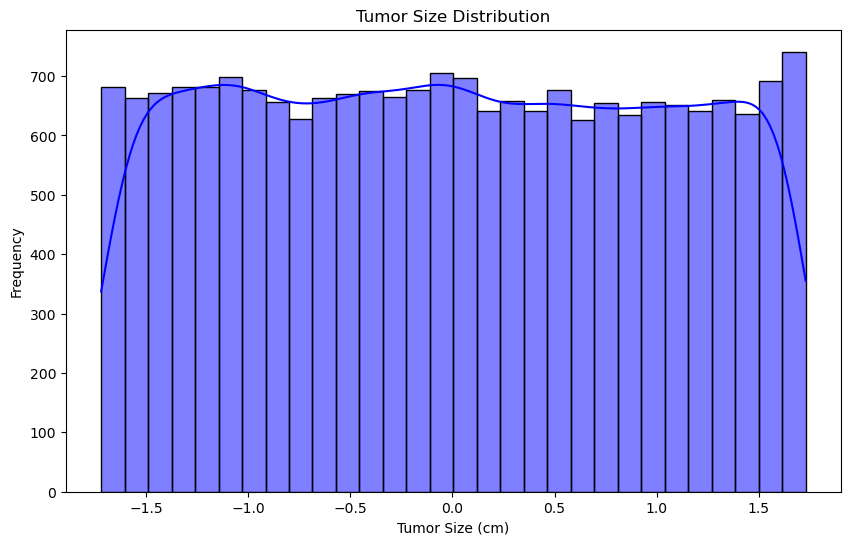

In [36]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Tumor_Size'], bins=30, kde=True, color='blue')
plt.title("Tumor Size Distribution")
plt.xlabel("Tumor Size (cm)")
plt.ylabel("Frequency")
plt.show()

In [38]:
### A histogram with a KDE overlay enables the visualization of the distribution of tumor sizes.
### This analysis can reveal whether larger tumors are more likely to be malignant or benign, providing valuable insights that can inform clinical decision-making processes.

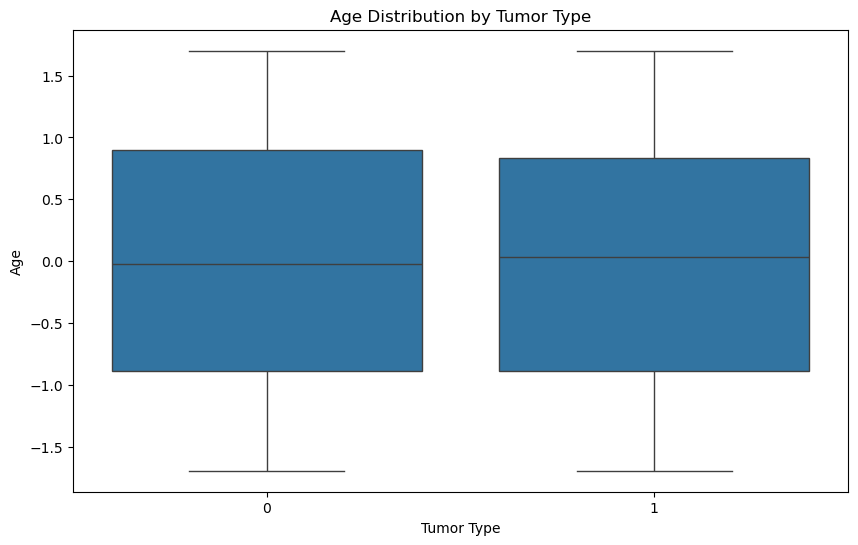

In [41]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Tumor_Type', y='Age', data=df)
plt.title("Age Distribution by Tumor Type")
plt.xlabel("Tumor Type")
plt.ylabel("Age")
plt.show()

In [43]:
### A boxplot is employed to visualize the distribution of age across tumor types.
### This visualization offers insights into whether specific age groups exhibit a higher propensity for benign or malignant tumors.

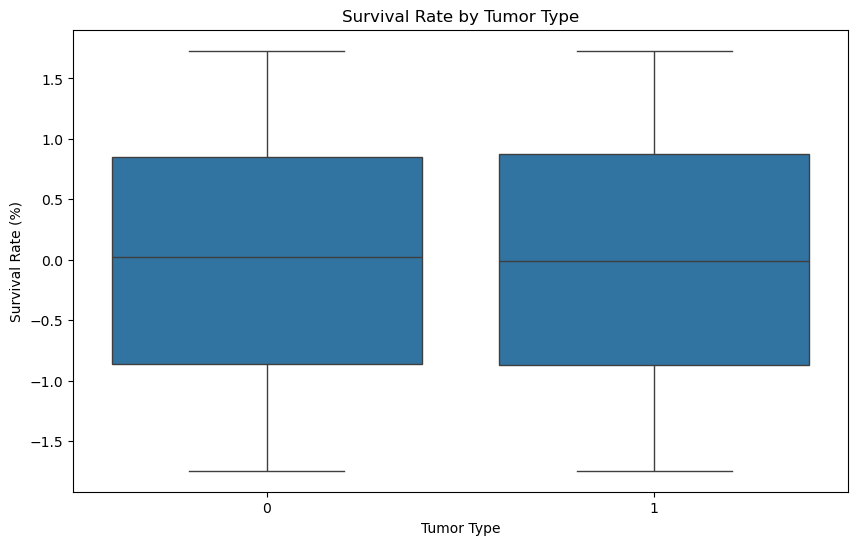

In [45]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Tumor_Type', y='Survival_Rate', data=df)
plt.title("Survival Rate by Tumor Type")
plt.xlabel("Tumor Type")
plt.ylabel("Survival Rate (%)")
plt.show()

In [47]:
### This visualization presents the distribution of survival rates among tumor types, enabling us to discern potential correlations between tumor types and their respective survival outcomes.
### This analysis is instrumental in comprehending the prognosis associated with the malignancy of the tumor.

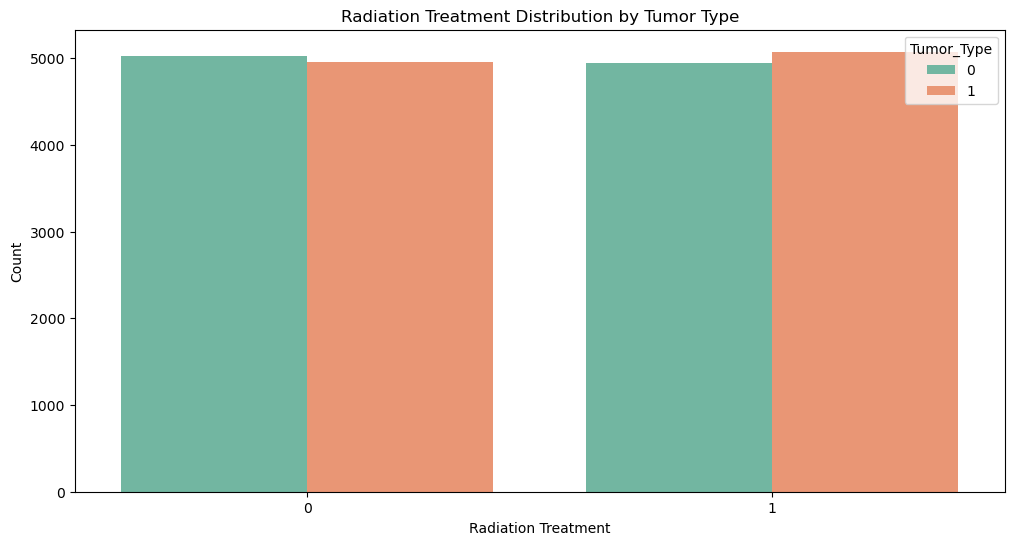

In [49]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Radiation_Treatment', hue='Tumor_Type', data=df, palette='Set2')
plt.title("Radiation Treatment Distribution by Tumor Type")
plt.xlabel("Radiation Treatment")
plt.ylabel("Count")
plt.show()

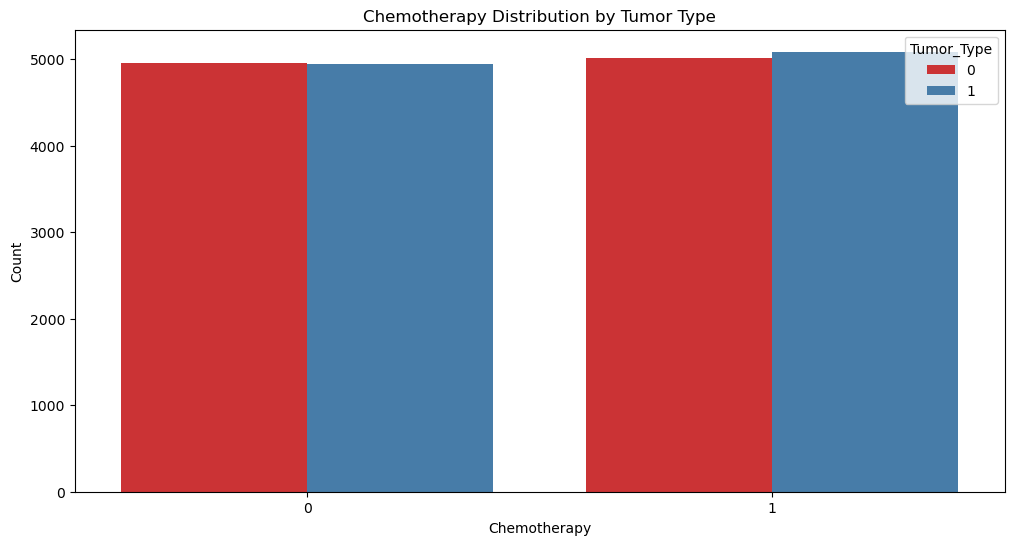

In [51]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Chemotherapy', hue='Tumor_Type', data=df, palette='Set1')
plt.title("Chemotherapy Distribution by Tumor Type")
plt.xlabel("Chemotherapy")
plt.ylabel("Count")
plt.show()

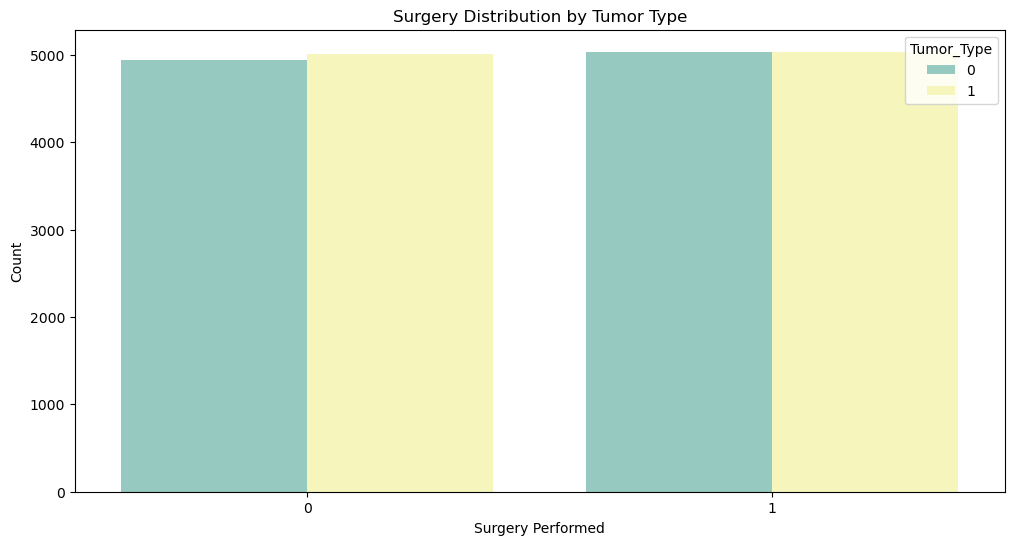

In [53]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Surgery_Performed', hue='Tumor_Type', data=df, palette='Set3')
plt.title("Surgery Distribution by Tumor Type")
plt.xlabel("Surgery Performed")
plt.ylabel("Count")
plt.show()

In [55]:
### Countplots are employed to visualize the distribution of radiation treatment, chemotherapy, and surgery performed in accordance with tumor type.
### This analysis facilitates the comprehension of treatment patterns for diverse tumor types and the potential impact of treatments on survival outcomes.

In [57]:
print("Correlation Matrix:")
print(df.corr())

Correlation Matrix:
                     Patient_ID       Age    Gender  Tumor_Type  Tumor_Size  \
Patient_ID             1.000000 -0.001774  0.002063   -0.000651    0.007371   
Age                   -0.001774  1.000000  0.004163    0.005734   -0.014385   
Gender                 0.002063  0.004163  1.000000   -0.003795    0.008140   
Tumor_Type            -0.000651  0.005734 -0.003795    1.000000   -0.014354   
Tumor_Size             0.007371 -0.014385  0.008140   -0.014354    1.000000   
Location              -0.001760 -0.004307  0.001763    0.013310   -0.008254   
Histology             -0.009851  0.002576 -0.002773    0.002230    0.001451   
Stage                  0.004842  0.001871  0.000844   -0.009620    0.009682   
Symptom_1              0.000622 -0.000523 -0.004613    0.000684    0.008697   
Symptom_2             -0.004774 -0.011938 -0.003748    0.012770   -0.018535   
Symptom_3              0.000831 -0.005988  0.012145    0.005856   -0.004087   
Radiation_Treatment    0.006357 

In [59]:
# Preparing the data for linear regression
X = df[['Age', 'Tumor_Size', 'Tumor_Growth_Rate']]
y = df['Survival_Rate']

In [61]:
# Splitting the data into training and testing sets (40% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

In [63]:
# Training linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [65]:
# Predict the survival rate
y_pred = model.predict(X_test)

In [74]:
# Calculate the RMSE and R2
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")

Mean Squared Error: 0.9991339341703207
R-squared Score: 9.027252327986623e-06


In [75]:
### Following the fitting of the linear regression model, we present the Mean Squared Error (MSE) and R-squared (R2) score. 
### MSE quantifies the magnitude of the discrepancy between our predictions and the actual values, while R2 assesses the extent to which the model aligns with the data. 
### These metrics are crucial for comprehending the predictive capabilities of the model.

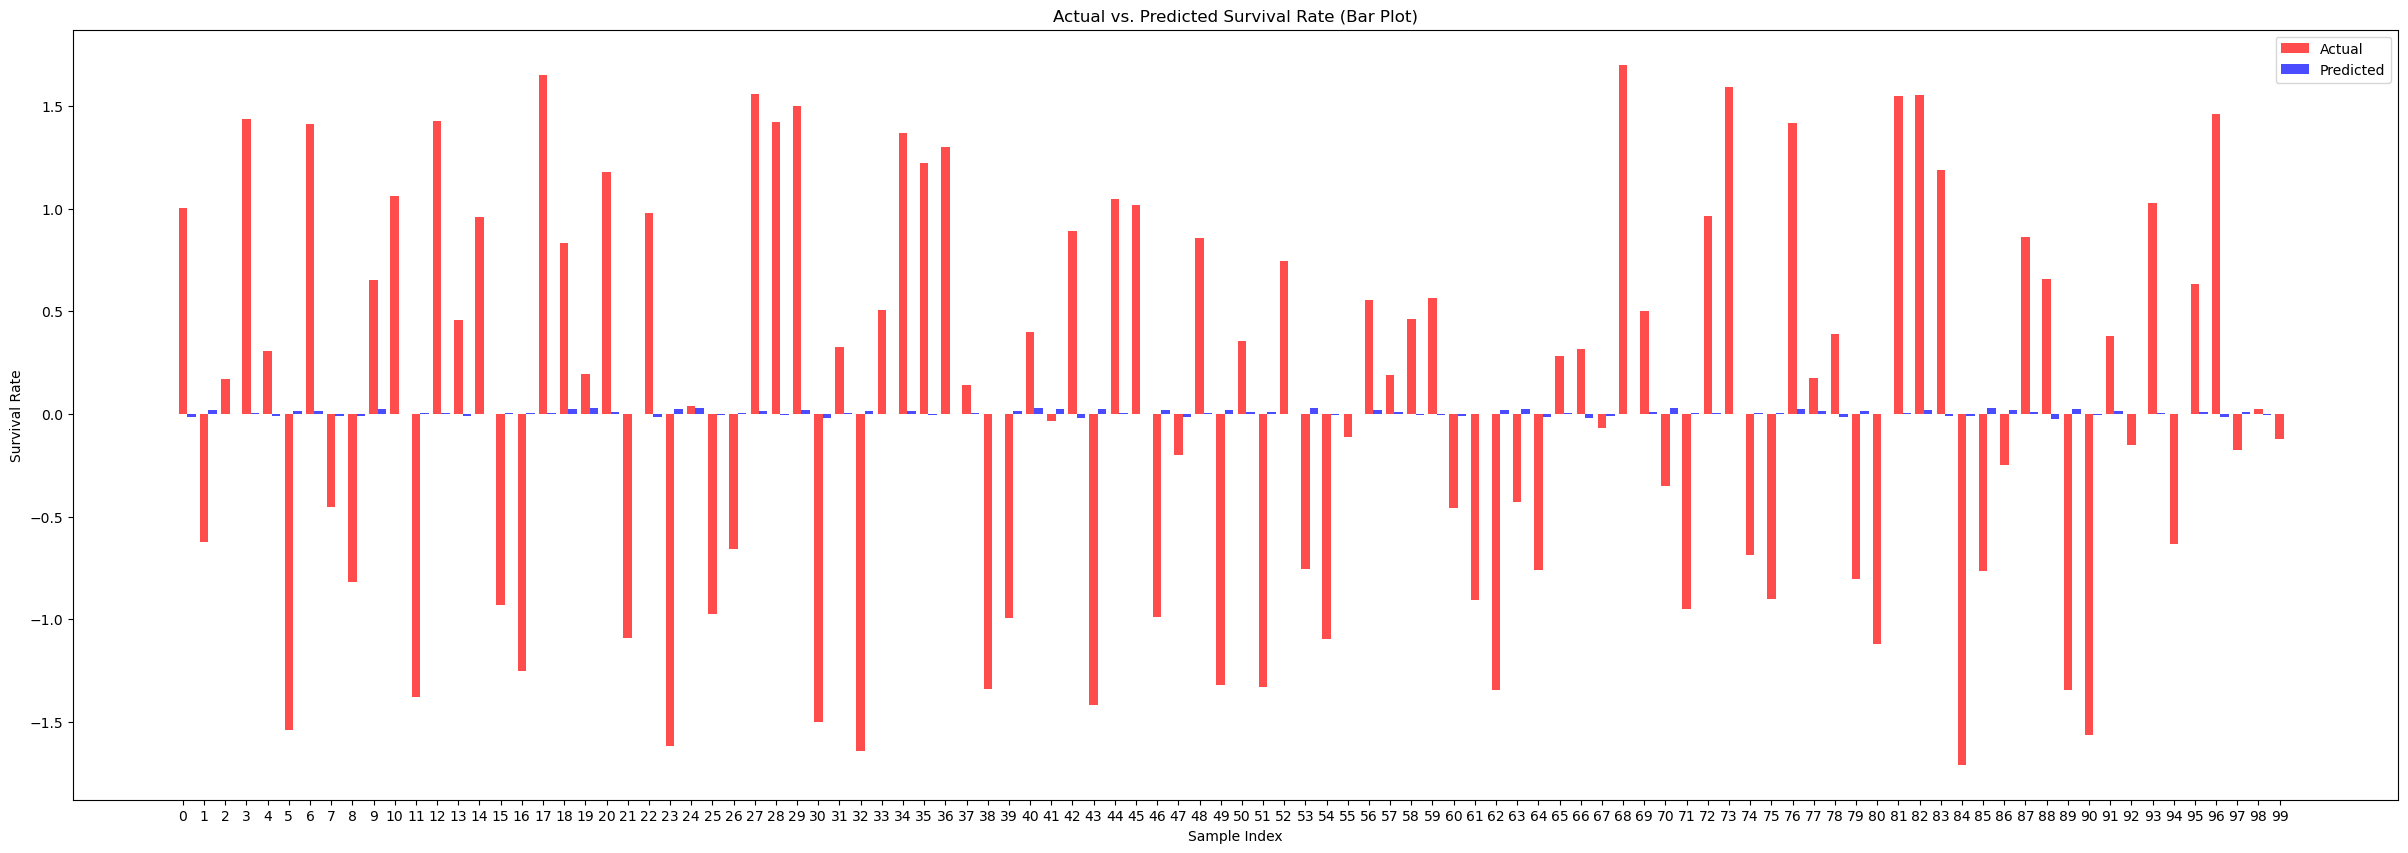

In [90]:
sample_size = 100
indices = np.random.choice(range(len(y_test)), sample_size, replace=False)
plt.figure(figsize=(30, 10))
x_labels = range(sample_size)
plt.bar(x_labels, y_test.iloc[indices], width=0.4, label="Actual", color="red", alpha=0.7)
plt.bar(np.array(x_labels) + 0.4, y_pred[indices], width=0.4, label="Predicted", color="blue", alpha=0.7)
plt.xlabel("Sample Index")
plt.ylabel("Survival Rate")
plt.title("Actual vs. Predicted Survival Rate (Bar Plot)")
plt.xticks(x_labels)
plt.legend()
plt.show()

In [93]:
### By comparing actual and predicted survival rates, we can visually evaluate the model’s performance.
### This plot clearly demonstrates whether the model’s predictions align closely with the actual values for a representative sample of test data.